Plots of chromosome & top 20 scaffolds across species + outgroups (_from ncbi_)

In [5]:
from pathlib import Path 
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [19]:
OUTDIR = Path("/hpcfs/users/a1864358/sanders_lab/asm/files/final-asms/backup")
RES = Path("/hpcfs/users/a1864358/sanders_lab/resources")
scut25 = Path("/hpcfs/users/a1864358/sanders_lab/resources/nscut/2025/nscut_2025.fa")
text25 = Path("/hpcfs/users/a1864358/sanders_lab/resources/ptext/2025/ptext_2025.fa")
TOP_N = 20
MB = 1e6

HYDROPHIS_CHR = ["ch1", "ch2", "ch3", "ch4", "ch5", "chZ", "ch7", "ch8"]

SPECIES = [
    ("hmaj", r"$\it{H.\ major}$", OUTDIR / "10-hmaj-final.renamed.fa", "hydrophis"),
    ("hcy", r"$\it{H.\ cyanocinctus}$", OUTDIR / "10-hcy-final.renamed.fa", "hydrophis"),
    ("hcure", r"$\it{H.\ curtus}$ E", OUTDIR / "10-hcure-final.renamed.fa", "hydrophis"),
    ("hcurw", r"$\it{H.\ curtus}$ W", OUTDIR / "10-hcurw-final.renamed.fa", "hydrophis"),
    ("horn", r"$\it{H.\ ornatus}$", OUTDIR / "10-horn-final.renamed.fa", "hydrophis"),
    ("cadam", r"$\it{C.\ adamanteus}$", RES / "cadam/cadam.fa", "cadam"),
    ("nscut", r"$\it{N.\ scutatus}$", scut25, "scaffold"),
    ("ptext", r"$\it{P.\ textilis}$", text25, "scaffold"),
]

In [20]:
def read_fai(fa: Path) -> list[tuple[str, int]]:
    rows = []
    with open(str(fa) + ".fai") as fh:
        for line in fh:
            name, length, *_ = line.split("\t")
            rows.append((name, int(length)))
    return rows

def fasta_header_map(fa: Path) -> dict[str, str]:
    mapping = {}
    import subprocess
    out = subprocess.check_output(["grep", "^>", str(fa)], text=True)
    for line in out.splitlines():
        rec = line[1:].rstrip()
        mapping[rec.split()[0]] = rec
    return mapping

In [21]:
def cadam_label(header: str) -> str | None:
    if re.search(r"mitochondrion", header, re.I):
        return None
    m = re.search(r"chromosome\s+(\S+?)(?:,|$)", header, re.I)
    if m:
        tok = m.group(1).rstrip(",")
        return f"chr{tok}"
    m = re.search(r"(Unplaced_\d+)", header, re.I)
    if m:
        return m.group(1)
    return header.split()[0]

In [22]:
def chr_sort_key(label: str):
    m = re.match(r"^chr(.+)$", label, re.I)
    if not m:
        return (2, 0, label)
    tok = m.group(1)
    if tok.upper() == "Z":
        return (0, 100, "Z")
    if tok.upper() == "W":
        return (0, 101, "W")
    try:
        return (0, int(tok), tok)
    except ValueError:
        return (0, 999, tok)

In [23]:
def pick_sequences(kind: str, fa: Path) -> tuple[list[str], list[float], list[str]]:
    fai = read_fai(fa)
    labels, sizes, cats = [], [], []

    if kind == "hydrophis":
        by_name = dict(fai)
        for c in HYDROPHIS_CHR:
            if c in by_name:
                labels.append(c)
                sizes.append(by_name[c] / MB)
                cats.append("chromosome")
        rest = [(n, L) for n, L in fai if n not in set(HYDROPHIS_CHR)]
        rest.sort(key=lambda x: -x[1])
        for n, L in rest[:TOP_N]:
            labels.append(n.replace("scaffold_", "scaf"))
            sizes.append(L / MB)
            cats.append("scaffold")
        return labels, sizes, cats

    if kind == "cadam":
        headers = fasta_header_map(fa)
        chroms, unplaced = [], []
        for name, L in fai:
            lab = cadam_label(headers.get(name, name))
            if lab is None:
                continue
            if lab.lower().startswith("chr"):
                chroms.append((lab, L))
            else:
                unplaced.append((lab, L))
        chroms.sort(key=lambda x: chr_sort_key(x[0]))
        unplaced.sort(key=lambda x: -x[1])
        for lab, L in chroms:
            labels.append(lab)
            sizes.append(L / MB)
            cats.append("chromosome")
        for lab, L in unplaced[:TOP_N]:
            labels.append(lab.replace("Unplaced_", "unp"))
            sizes.append(L / MB)
            cats.append("scaffold")
        return labels, sizes, cats

    # scaffold-only assemblies: top 20
    ranked = sorted(fai, key=lambda x: -x[1])[:TOP_N]
    for i, (name, L) in enumerate(ranked, 1):
        labels.append(str(i))
        sizes.append(L / MB)
        cats.append("scaffold")
    return labels, sizes, cats

wrote /hpcfs/users/a1864358/sanders_lab/asm/files/final-asms/backup/chr_scaffold_sizes.png
shared ymax = 474.9 Mb
hmaj    n=28  chr_sum= 1987.3 Mb  largest_scaf=   8.39 Mb
hcy     n=28  chr_sum= 1925.9 Mb  largest_scaf=   0.97 Mb
hcure   n=28  chr_sum= 1815.1 Mb  largest_scaf=   2.21 Mb
hcurw   n=28  chr_sum= 2056.0 Mb  largest_scaf=   1.18 Mb
horn    n=28  chr_sum= 1987.9 Mb  largest_scaf=   0.60 Mb
cadam   n=26  chr_sum= 1694.3 Mb  largest_scaf=   0.64 Mb
nscut   n=20  chr_sum=    0.0 Mb  largest_scaf= 340.82 Mb
ptext   n=20  chr_sum=    0.0 Mb  largest_scaf= 332.84 Mb


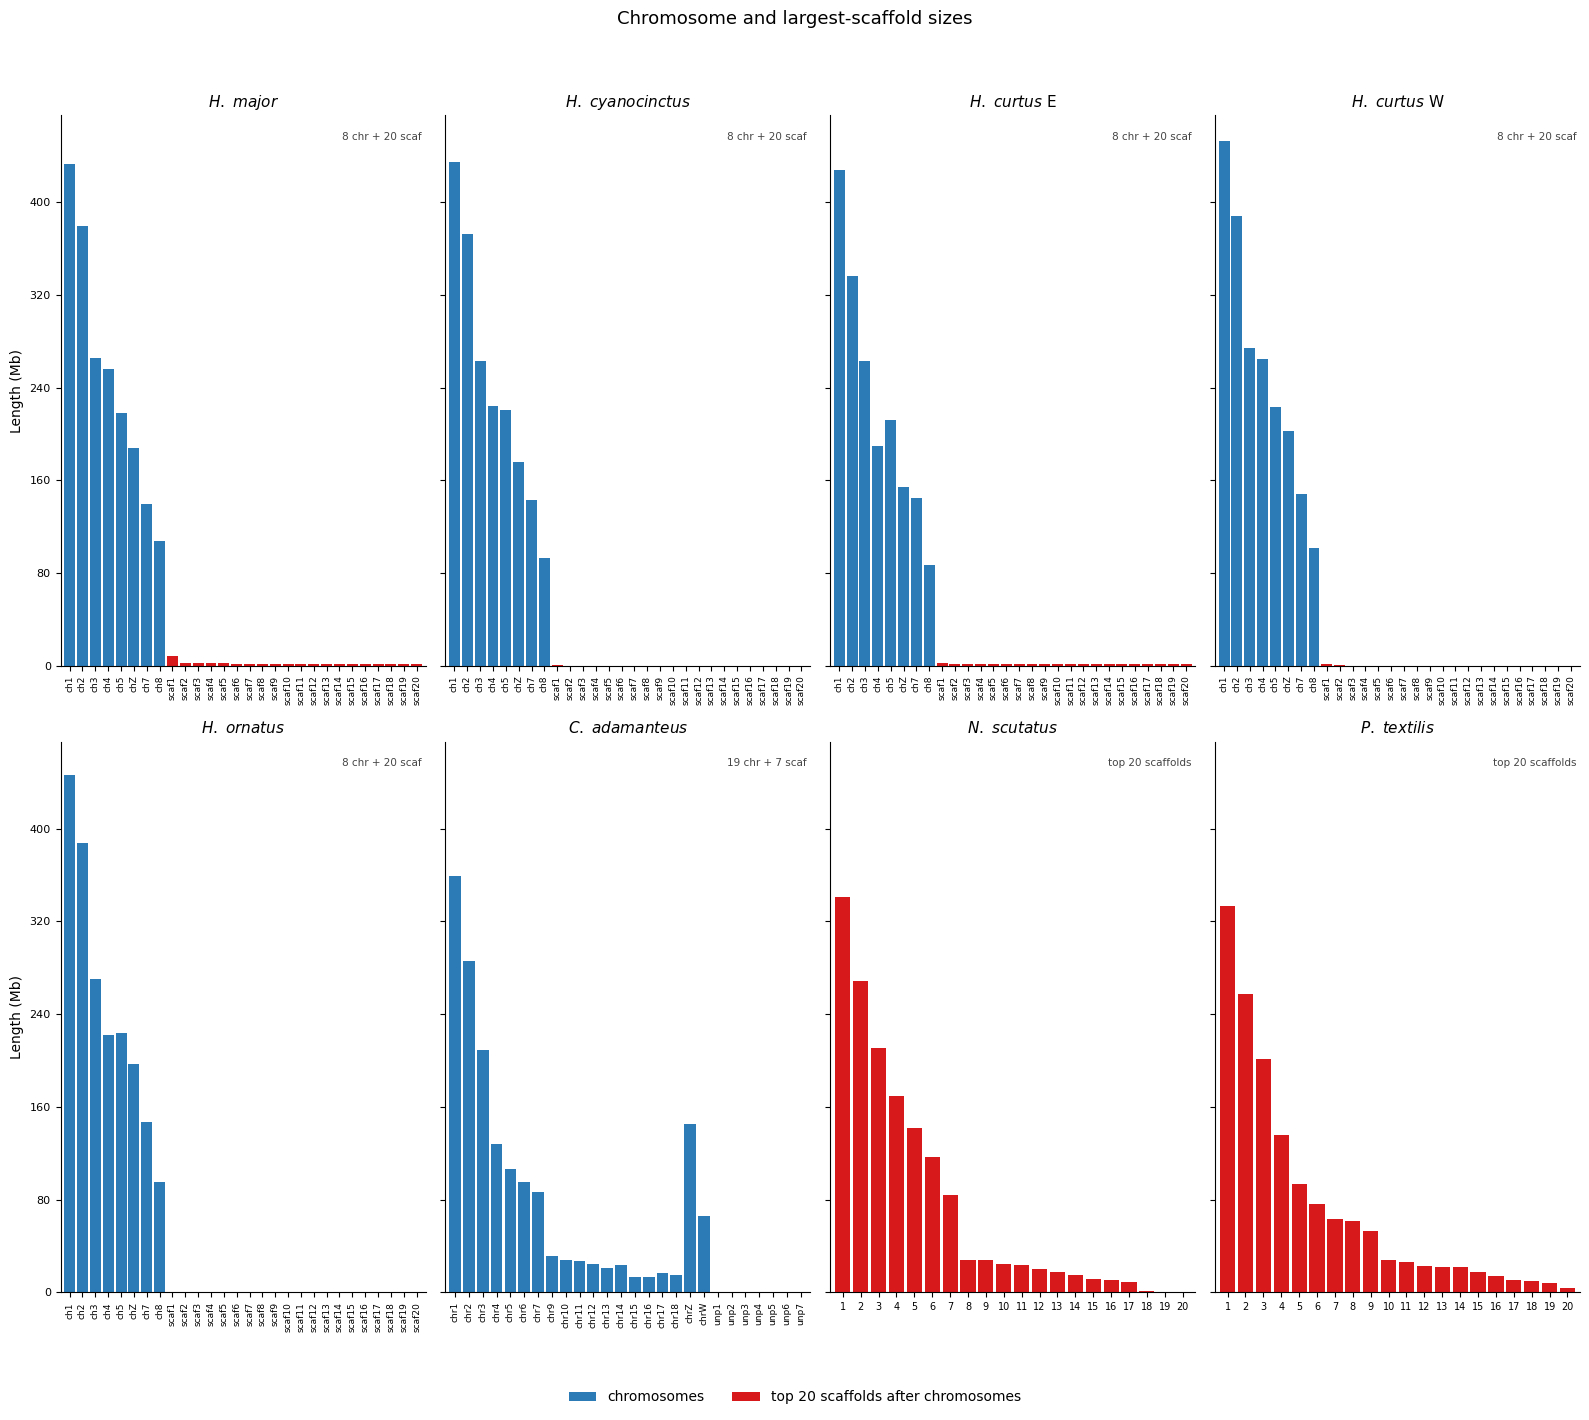

In [26]:
def main():
    panels = []
    ymax = 0
    for code, title, fa, kind in SPECIES:
        labels, sizes, cats = pick_sequences(kind, fa)
        ymax = max(ymax, max(sizes) if sizes else 0)
        panels.append((code, title, labels, sizes, cats, kind))

    ymax *= 1.05
    fig, axes = plt.subplots(2, 4, figsize=(16, 14), sharey=True)
    axes = axes.ravel()
    chr_c = "#2c7bb6"
    scaf_c = "#d7191c"

    for ax, (code, title, labels, sizes, cats, kind) in zip(axes, panels):
        colors = [chr_c if c == "chromosome" else scaf_c for c in cats]
        ax.bar(range(len(sizes)), sizes, color=colors, width=0.85, linewidth=0)
        ax.set_title(title, fontsize=11, pad=6)
        ax.set_ylim(0, ymax)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(-0.7, len(sizes) - 0.3)
        if kind == "scaffold":
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, fontsize=7)
        else:
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=90, fontsize=6.5, ha="center")
        n_chr = sum(c == "chromosome" for c in cats)
        n_scaf = sum(c == "scaffold" for c in cats)
        note = f"{n_chr} chr + {n_scaf} scaf" if n_chr else f"top {n_scaf} scaffolds"
        ax.text(0.99, 0.97, note, transform=ax.transAxes, ha="right", va="top",
                fontsize=7.5, color="#444444")

    axes[0].set_ylabel("Length (Mb)")
    axes[4].set_ylabel("Length (Mb)")
    for ax in axes:
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
        ax.tick_params(axis="y", labelsize=8)

    from matplotlib.patches import Patch
    fig.legend(
        handles=[
            Patch(facecolor=chr_c, label="chromosomes"),
            Patch(facecolor=scaf_c, label="top 20 scaffolds after chromosomes"),
        ],
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.5, -0.01),
    )
    fig.suptitle("Chromosome and largest-scaffold sizes", fontsize=13, y=0.995)
    fig.tight_layout(rect=[0, 0.04, 1, 0.97])
    png = OUTDIR / "chr_scaffold_sizes.png"
    fig.savefig(png, dpi=300)
    print(f"wrote {png}")
    print(f"shared ymax = {ymax:.1f} Mb")
    for code, title, labels, sizes, cats, kind in panels:
        tot = sum(s for s, c in zip(sizes, cats) if c == "chromosome")
        scaf_max = max((s for s, c in zip(sizes, cats) if c == "scaffold"), default=0)
        print(f"{code:6s}  n={len(sizes):2d}  chr_sum={tot:7.1f} Mb  largest_scaf={scaf_max:7.2f} Mb")


if __name__ == "__main__":
    main()